# Capstone Project: Style Transfer using Generative Adversarial Network (GAN)

## Project Overview

This Capstone project explores the application of Generative Adversarial Networks (GANs), specifically CycleGAN, for cross-modality translation of Magnetic Resonance Imaging (MRI) scans. The core objective is to synthesize T2-weighted MRI images from T1-weighted inputs and vice-versa. This capability holds significant potential for clinical applications, including data augmentation, reducing scanning times, and enhancing diagnostic insights where certain MRI modalities might be unavailable or suboptimal. By leveraging the CycleGAN architecture, we aim to demonstrate robust image-to-image translation without requiring paired training data, addressing a common challenge in medical imaging datasets.

In [1]:
import tensorflow as tf # Import the TensorFlow library for deep learning operations
import numpy as np # Import NumPy for numerical operations
import matplotlib.pyplot as plt # Import Matplotlib for plotting and visualization
import os # Import the os module for interacting with the operating system (e.g., file paths)
import time # Import the time module for time-related functions (e.g., measuring epoch duration)
import datetime # Import datetime for generating timestamps (e.g., for saving files)

from IPython.display import clear_output # Import clear_output to clear cell output in Colab

## Model Architecture: Generator and Discriminator Components

The CycleGAN framework necessitates the development of two generator networks for bidirectional translation (Domain A to B, and Domain B to A) and two discriminator networks (one for each domain).

### Generator Architecture: U-Net

Each generator employs a U-Net architecture, renowned for its effectiveness in image-to-image translation tasks, particularly in medical imaging. The U-Net's design features a symmetric encoder-decoder structure with skip connections. This allows for the propagation of fine-grained spatial information directly from the encoder to corresponding decoder layers, which is crucial for producing high-fidelity output images.

### Discriminator Architecture: PatchGAN

For the discriminator, a PatchGAN architecture is utilized. Unlike traditional discriminators that classify an entire image as real or fake, a PatchGAN operates on local `N x N` patches of the image. This encourages the generator to produce realistic textures and high-frequency details across the entire synthesized image, rather than merely focusing on global realism.

In [2]:
OUTPUT_CHANNELS = 3

def downsample(filters, size, apply_batchnorm=True):
  initializer = tf.random_normal_initializer(0., 0.02)
  result = tf.keras.Sequential()
  # Add a Conv2D layer for downsampling, with stride 2 to halve dimensions
  result.add(tf.keras.layers.Conv2D(filters, size, strides=2, padding='same',
                                    kernel_initializer=initializer, use_bias=False))
  # Optionally apply BatchNormalization for stable training
  if apply_batchnorm:
    result.add(tf.keras.layers.BatchNormalization())
  # Use LeakyReLU activation for non-linearity in the encoder
  result.add(tf.keras.layers.LeakyReLU())
  return result

def upsample(filters, size, apply_dropout=False):
  initializer = tf.random_normal_initializer(0., 0.02)
  result = tf.keras.Sequential()
  # Add a Conv2DTranspose layer for upsampling, with stride 2 to double dimensions
  result.add(tf.keras.layers.Conv2DTranspose(filters, size, strides=2,
                                            padding='same',
                                            kernel_initializer=initializer,
                                            use_bias=False))
  # Apply BatchNormalization
  result.add(tf.keras.layers.BatchNormalization())
  # Optionally apply Dropout for regularization (e.g., in earlier upsampling layers)
  if apply_dropout:
    result.add(tf.keras.layers.Dropout(0.5))
  # Use ReLU activation for non-linearity in the decoder
  result.add(tf.keras.layers.ReLU())
  return result

def Generator():
  # Input layer for images, typically 256x256 with 3 channels
  inputs = tf.keras.layers.Input(shape=[256, 256, 3])

  # Encoder (Downsampling) stack
  down_stack = [
      downsample(64, 4, apply_batchnorm=False),  # (bs, 128, 128, 64)
      downsample(128, 4),  # (bs, 64, 64, 128)
      downsample(256, 4),  # (bs, 32, 32, 256)
      downsample(512, 4),  # (bs, 16, 16, 512)
      downsample(512, 4),  # (bs, 8, 8, 512)
      downsample(512, 4),  # (bs, 4, 4, 512)
      downsample(512, 4),  # (bs, 2, 2, 512)
      downsample(512, 4),  # (bs, 1, 1, 512) - Bottleneck layer
  ]

  # Decoder (Upsampling) stack
  up_stack = [
      upsample(512, 4, apply_dropout=True),  # (bs, 2, 2, 1024) after concatenation
      upsample(512, 4, apply_dropout=True),  # (bs, 4, 4, 1024)
      upsample(512, 4, apply_dropout=True),  # (bs, 8, 8, 1024)
      upsample(512, 4),  # (bs, 16, 16, 1024)
      upsample(256, 4),  # (bs, 32, 32, 512)
      upsample(128, 4),  # (bs, 64, 64, 256)
      upsample(64, 4),  # (bs, 128, 128, 128)
  ]

  initializer = tf.random_normal_initializer(0., 0.02)
  # Final output layer: Conv2DTranspose to match original image size and channels
  # Tanh activation is common in GANs for outputting pixel values in [-1, 1]
  last = tf.keras.layers.Conv2DTranspose(OUTPUT_CHANNELS, 4,
                                         strides=2,
                                         padding='same',
                                         kernel_initializer=initializer,
                                         activation='tanh')  # (bs, 256, 256, 3)

  x = inputs

  # Downsampling through the model and storing skip connections
  skips = []
  for down in down_stack:
    x = down(x)
    skips.append(x)

  # Reverse skips for upsampling, excluding the last (bottleneck) skip
  skips = reversed(skips[:-1])

  # Upsampling and establishing the skip connections
  # Concatenate output of upsample with corresponding skip connection from down_stack
  for up, skip in zip(up_stack, skips):
    x = up(x)
    x = tf.keras.layers.Concatenate()([x, skip])

  # Apply the final output layer
  x = last(x)

  # Create and return the Keras Model
  return tf.keras.Model(inputs=inputs, outputs=x)

In [3]:
def Discriminator():
  # Initialize weights using a normal distribution for Conv2D layers
  initializer = tf.random_normal_initializer(0., 0.02)

  # The discriminator takes an image as input (e.g., 256x256 with 3 channels)
  inp = tf.keras.layers.Input(shape=[256, 256, OUTPUT_CHANNELS], name='input_image')

  x = inp # Start processing with the input image

  # Downsampling layers (similar to the encoder of the Generator, but without skip connections)
  # Each downsample layer reduces spatial dimensions and increases feature maps
  down1 = downsample(64, 4, False)(x)  # (bs, 128, 128, 64)
  down2 = downsample(128, 4)(down1)  # (bs, 64, 64, 128)
  down3 = downsample(256, 4)(down2)  # (bs, 32, 32, 256)

  # Zero padding for the next convolutional layer to maintain desired output size
  zero_pad1 = tf.keras.layers.ZeroPadding2D()(down3)  # (bs, 34, 34, 256)

  # Convolutional layer to extract features from the downsampled image
  conv = tf.keras.layers.Conv2D(512, 4, strides=1, # 512 filters, 4x4 kernel, stride 1
                                kernel_initializer=initializer, # Weight initializer
                                use_bias=False)(zero_pad1)  # (bs, 31, 31, 512)

  # Batch Normalization for stable training
  batchnorm1 = tf.keras.layers.BatchNormalization()(conv)

  # Leaky ReLU activation for non-linearity
  leaky_relu = tf.keras.layers.LeakyReLU()(batchnorm1)

  # Second zero padding layer
  zero_pad2 = tf.keras.layers.ZeroPadding2D()(leaky_relu)  # (bs, 33, 33, 512)

  # Final convolutional layer to output a single channel representing the discriminator's prediction
  # Output size of (bs, 30, 30, 1) means it's a PatchGAN, predicting real/fake for 30x30 patches
  last = tf.keras.layers.Conv2D(1, 4, strides=1, # 1 filter (real/fake output), 4x4 kernel, stride 1
                                kernel_initializer=initializer)(zero_pad2)  # (bs, 30, 30, 1)

  # Return the Keras Model mapping the input image to the discriminator's output
  return tf.keras.Model(inputs=inp, outputs=last)

In [4]:
generator = Generator() # Instantiate the Generator model
print(generator.summary()) # Print a summary of the Generator's architecture

Model: "functional_15"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential          │ (None, 128, 128,  │      3,072 │ input_layer[0][0] │
│ (Sequential)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_1        │ (None, 64, 64,    │    131,584 │ sequential[0][0]  │
│ (Sequential)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_2        │ (None, 32, 32,    │    525,312 │ sequential_1[0][… │
│ (Sequential)        │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_3        │ (None, 16, 16,    │  2,099,200 │ sequential_2[0][… │
│ (Sequential)        │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_4        │ (None, 8, 8, 512) │  4,196,352 │ sequential_3[0][… │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_5        │ (None, 4, 4, 512) │  4,196,352 │ sequential_4[0][… │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_6        │ (None, 2, 2, 512) │  4,196,352 │ sequential_5[0][… │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_7        │ (None, 1, 1, 512) │  4,196,352 │ sequential_6[0][… │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_8        │ (None, 2, 2, 512) │  4,196,352 │ sequential_7[0][… │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 2, 2,      │          0 │ sequential_8[0][… │
│ (Concatenate)       │ 1024)             │            │ sequential_6[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_9        │ (None, 4, 4, 512) │  8,390,656 │ concatenate[0][0] │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 4, 4,      │          0 │ sequential_9[0][… │
│ (Concatenate)       │ 1024)             │            │ sequential_5[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_10       │ (None, 8, 8, 512) │  8,390,656 │ concatenate_1[0]… │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_2       │ (None, 8, 8,      │          0 │ sequential_10[0]… │
│ (Concatenate)       │ 1024)             │            │ sequential_4[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_11       │ (None, 16, 16,    │  8,390,656 │ concatenate_2[0]… │
│ (Sequential)        │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_3       │ (None, 16, 16,    │          0 │ sequential_11[0]

 Total params: 54,425,859 (207.62 MB)

 Trainable params: 54,414,979 (207.58 MB)

 Non-trainable params: 10,880 (42.50 KB)

None


In [5]:
discriminator = Discriminator() # Instantiate the Discriminator model
print(discriminator.summary()) # Print a summary of the Discriminator's architecture

Model: "functional_19"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_15 (Sequential)      │ (None, 128, 128, 64)   │         3,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_16 (Sequential)      │ (None, 64, 64, 128)    │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_17 (Sequential)      │ (None, 32, 32, 256)    │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ zero_padding2d (ZeroPadding2D)  │ (None, 34, 34, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 31, 31, 512)    │     2,097,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (None, 31, 31, 512)    │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_11 (LeakyReLU)      │ (None, 31, 31, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ zero_padding2d_1                │ (None, 33, 33, 512)    │             0 │
│ (ZeroPadding2D)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 30, 30, 1)      │         8,193 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,767,361 (10.56 MB)

 Trainable params: 2,765,569 (10.55 MB)

 Non-trainable params: 1,792 (7.00 KB)

None


## Data Acquisition and Preprocessing

Effective training of deep learning models, especially GANs, relies heavily on meticulously prepared data. This section outlines the loading, resizing, and normalization steps applied to our MRI dataset. The primary goal is to transform raw image files into a standardized format suitable for model ingestion, ensuring consistency and optimizing training stability. Key operations include decoding images, uniform resizing to `256x256` pixels, and normalizing pixel intensities to the `[-1, 1]` range, which is a common practice for GANs due to the `tanh` activation function often used in the generator's output layer.

In [6]:
IMG_WIDTH = 256 # Define the target width for images
IMG_HEIGHT = 256 # Define the target height for images

def resize(image, height, width):
  # Resize the image to the specified height and width using Nearest Neighbor interpolation
  image = tf.image.resize(image, [height, width],
                          method=tf.image.ResizeMethod.NEAREST_NEIGHBOR)
  return image

def random_crop(image):
  # Randomly crop the image to the target IMG_HEIGHT and IMG_WIDTH
  # Assumes input image is larger than target size (e.g., 286x286 for 256x256 target)
  cropped_image = tf.image.random_crop(
      image, size=[IMG_HEIGHT, IMG_WIDTH, 3]) # Expects 3 channels for RGB/grayscale with 3 channels
  return cropped_image

# Normalizing the images to [-1, 1] for compatibility with tanh activation in Generator output
def normalize(image):
  image = tf.cast(image, tf.float32) # Cast image pixels to float32
  image = (image / 127.5) - 1 # Normalize from [0, 255] to [-1, 1]
  return image

def random_jitter(image):
  # Apply various data augmentation techniques for training
  # Resizing to 286x286 first, then random cropping to 256x256
  image = resize(image, 286, 286)
  # Random cropping back to 256x256
  image = random_crop(image)
  # Random mirror (horizontal flip) for more diversity
  image = tf.image.random_flip_left_right(image)
  return image

def load_image_train(image_file):
  # Load, decode, augment, and normalize a training image
  image = tf.io.read_file(image_file) # Read the image file from path
  image = tf.image.decode_png(image, channels=3) # Decode PNG to a 3-channel image tensor
  image = random_jitter(image) # Apply random jitter for augmentation
  image = normalize(image) # Normalize pixel values to [-1, 1]
  return image

def load_image_test(image_file):
  # Load, decode, resize, and normalize a test image (no random jitter)
  image = tf.io.read_file(image_file) # Read the image file from path
  image = tf.image.decode_png(image, channels=3) # Decode PNG to a 3-channel image tensor
  image = resize(image, IMG_HEIGHT, IMG_WIDTH) # Resize to target dimensions
  image = normalize(image) # Normalize pixel values to [-1, 1]
  return image

## Loss Functions Employed in CycleGAN

CycleGAN's robust image translation capabilities are achieved through a combination of carefully designed loss functions:

*   **Discriminator Loss**: This is a fundamental adversarial loss, typically implemented using binary cross-entropy. Its objective is to enable the discriminator to accurately distinguish between real images (from the dataset) and fake images (generated by the generator). The discriminator is optimized to maximize this loss, while the generators aim to minimize it.

*   **Generator Adversarial Loss**: This loss encourages the generators to produce outputs that are indistinguishable from real images in the target domain, thereby 'fooling' the respective discriminators. It also utilizes binary cross-entropy and is optimized to achieve a classification of 'real' for the generated images.

*   **Cycle Consistency Loss**: A cornerstone of the CycleGAN architecture, this loss enforces the principle that if an image `x` from Domain A is translated to Domain B by Generator G (yielding `y`), and then `y` is translated back to Domain A by Generator F (yielding `x'`), then `x` and `x'` should be as perceptually close as possible. This bidirectional consistency is typically quantified using an L1 loss (Mean Absolute Error) and prevents mode collapse and ensures meaningful translations.

*   **Identity Loss**: This auxiliary loss encourages the generators to maintain the original color composition when an image is translated into its own domain. Specifically, if Generator G (A to B) receives an image from Domain B, it should ideally produce an output very similar to the input. This is also an L1 loss, promoting color preservation and preventing unnecessary alterations.

In [7]:

# Binary cross-entropy loss for discriminators
loss_obj = tf.keras.losses.BinaryCrossentropy(from_logits=True)

def discriminator_loss(real, generated):
  real_loss = loss_obj(tf.ones_like(real), real)
  generated_loss = loss_obj(tf.zeros_like(generated), generated)
  total_disc_loss = real_loss + generated_loss
  return total_disc_loss

def generator_loss(generated):
  return loss_obj(tf.ones_like(generated), generated)

def calc_cycle_loss(real_image, cycled_image):
  loss1 = tf.reduce_mean(tf.abs(real_image - cycled_image))
  return LAMBDA * loss1

def identity_loss(real_image, same_image):
  loss = tf.reduce_mean(tf.abs(real_image - same_image))
  return LAMBDA * 0.5 * loss

# Re-definition of the train_step function to ensure it is re-traced
# with the newly defined loss functions.
# This code is duplicated from cell bb23d0d5 to satisfy the constraint
# of generating code only within this cell.
@tf.function
def train_step(real_x, real_y):
  with tf.GradientTape(persistent=True) as tape:
    fake_y = generator_g(real_x, training=True)
    cycled_x = generator_f(fake_y, training=True)

    fake_x = generator_f(real_y, training=True)
    cycled_y = generator_g(fake_x, training=True)

    same_x = generator_f(real_x, training=True)
    same_y = generator_g(real_y, training=True)

    disc_real_x = discriminator_x(real_x, training=True)
    disc_real_y = discriminator_y(real_y, training=True)

    disc_fake_x = discriminator_x(fake_x, training=True)
    disc_fake_y = discriminator_y(fake_y, training=True)

    gen_g_loss = generator_loss(disc_fake_y)
    gen_f_loss = generator_loss(disc_fake_x)

    total_cycle_loss = calc_cycle_loss(real_x, cycled_x) + calc_cycle_loss(real_y, cycled_y)

    total_gen_g_loss = gen_g_loss + total_cycle_loss + identity_loss(real_y, same_y)
    total_gen_f_loss = gen_f_loss + total_cycle_loss + identity_loss(real_x, same_x)

    disc_x_loss = discriminator_loss(disc_real_x, disc_fake_x)
    disc_y_loss = discriminator_loss(disc_real_y, disc_fake_y)

  generator_g_gradients = tape.gradient(total_gen_g_loss,
                                        generator_g.trainable_variables)
  generator_f_gradients = tape.gradient(total_gen_f_loss,
                                        generator_f.trainable_variables)

  discriminator_x_gradients = tape.gradient(disc_x_loss,
                                            discriminator_x.trainable_variables)
  discriminator_y_gradients = tape.gradient(disc_y_loss,
                                            discriminator_y.trainable_variables)

  generator_g_optimizer.apply_gradients(zip(generator_g_gradients,
                                            generator_g.trainable_variables))
  generator_f_optimizer.apply_gradients(zip(generator_f_gradients,
                                            generator_f.trainable_variables))

  discriminator_x_optimizer.apply_gradients(zip(discriminator_x_gradients,
                                                discriminator_x.trainable_variables))
  discriminator_y_optimizer.apply_gradients(zip(discriminator_y_gradients,
                                                discriminator_y.trainable_variables))


## Dataset Integration from Google Drive

To facilitate convenient access and management of the MRI dataset, Google Drive is utilized as the primary storage solution. The following steps outline the process of mounting Google Drive, identifying the dataset's location, and preparing it for ingestion by the TensorFlow `tf.data` API. The dataset is structured into 'train' and 'test' subsets, each containing subfolders for Domain A (T1-weighted MRI) and Domain B (T2-weighted MRI), enabling distinct training and evaluation phases for the CycleGAN.

In [8]:
# Import the drive module from google.colab to access Google Drive
from google.colab import drive
# Mount Google Drive to the Colab environment, making its contents accessible
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [9]:
import os # Import the os module for path manipulation

# Define the path to the dataset folder directly in Google Drive
# This assumes your dataset folder is named 'MRI-T1-T2-Dataset-1' and is in your MyDrive.
PATH = "/content/drive/MyDrive/MRI-T1-T2-Dataset-1"
# Verify contents of the GDrive folder by listing its contents
print(f"Contents of dataset directory in Google Drive ({PATH}):")
!ls {PATH} # Execute a shell command to list directory contents

Contents of dataset directory in Google Drive (/content/drive/MyDrive/MRI-T1-T2-Dataset-1):
cyclegan_checkpoints  generated_mri_output  testA  testB  trainA  trainB


In [10]:
# Define dataset paths assuming a typical structure after extraction
# PATH is now defined in the previous cell and points directly to the GDrive folder.

BUFFER_SIZE = 1000 # Buffer size for shuffling the dataset
BATCH_SIZE = 1 # Number of images per batch (initially set to 1 for illustration)

# Paths to the individual image folders for training and testing domains A and B
# Assuming 'trainA' contains T1 images, 'trainB' contains T2 images, etc.
# You might need to adjust these paths based on the actual extracted directory structure.
TRAIN_PATH_A = os.path.join(PATH, 'trainA') # e.g., T1 weighted MRI training images
TRAIN_PATH_B = os.path.join(PATH, 'trainB') # e.g., T2 weighted MRI training images
TEST_PATH_A = os.path.join(PATH, 'testA')   # e.g., T1 weighted MRI test images
TEST_PATH_B = os.path.join(PATH, 'testB')   # e.g., T2 weighted MRI test images

# Get lists of image files from the specified paths, assuming .png format
# shuffle=False for list_files as shuffling will be handled by the dataset.shuffle()
train_dataset_A_files = tf.data.Dataset.list_files(TRAIN_PATH_A + '/*.png', shuffle=False)
train_dataset_B_files = tf.data.Dataset.list_files(TRAIN_PATH_B + '/*.png', shuffle=False)
test_dataset_A_files = tf.data.Dataset.list_files(TEST_PATH_A + '/*.png', shuffle=False)
test_dataset_B_files = tf.data.Dataset.list_files(TEST_PATH_B + '/*.png', shuffle=False)

# Create datasets using the preprocessing functions, removed .cache() to ensure latest functions are used
# .map applies a function to each element of the dataset
# .shuffle shuffles the elements of the dataset
# .batch combines consecutive elements into batches
# num_parallel_calls=tf.data.AUTOTUNE allows TensorFlow to dynamically set the number of parallel calls
train_dataset_A = train_dataset_A_files.map(load_image_train, num_parallel_calls=tf.data.AUTOTUNE).shuffle(BUFFER_SIZE).batch(BATCH_SIZE)
train_dataset_B = train_dataset_B_files.map(load_image_train, num_parallel_calls=tf.data.AUTOTUNE).shuffle(BUFFER_SIZE).batch(BATCH_SIZE)

test_dataset_A = test_dataset_A_files.map(load_image_test, num_parallel_calls=tf.data.AUTOTUNE).batch(BATCH_SIZE)
test_dataset_B = test_dataset_B_files.map(load_image_test, num_parallel_calls=tf.data.AUTOTUNE).batch(BATCH_SIZE)

# Print the number of images loaded into each dataset for verification
print(f"Number of training images in domain A: {tf.data.experimental.cardinality(train_dataset_A).numpy() * BATCH_SIZE}")
print(f"Number of training images in domain B: {tf.data.experimental.cardinality(train_dataset_B).numpy() * BATCH_SIZE}")
print(f"Number of test images in domain A: {tf.data.experimental.cardinality(test_dataset_A).numpy() * BATCH_SIZE}")
print(f"Number of test images in domain B: {tf.data.experimental.cardinality(test_dataset_B).numpy() * BATCH_SIZE}")

Number of training images in domain A: 37
Number of training images in domain B: 36
Number of test images in domain A: 6
Number of test images in domain B: 10


## Hyperparameter Optimization for Performance

To enhance the quality of the generated MRI images and mitigate potential artifacts, a crucial step involves fine-tuning the model's hyperparameters. This iterative process aims to identify configurations that lead to more stable training and superior image synthesis. Key hyperparameters targeted for adjustment include:

1.  **Increase `LAMBDA`**: The `LAMBDA` parameter dictates the weighting of the cycle consistency loss within the total loss function. A higher `LAMBDA` value enforces a stricter adherence to cycle consistency, which can result in more faithful and accurate image translations. Initially set to 10, increasing it to 20 or 30 can significantly impact output quality.
2.  **Increase `EPOCHS`**: The number of training epochs directly influences the model's capacity to learn comprehensive representations. Ten epochs might be insufficient for full convergence; extending this to 50, 100, or more can allow generators and discriminators to achieve better equilibrium and produce higher-quality imagery.
3.  **Adjust Learning Rates**: While a learning rate of `2e-4` is a standard starting point, experimentation with slightly reduced rates (e.g., `1e-4`) or the implementation of a learning rate scheduler (e.g., exponential decay) can often stabilize training dynamics and improve convergence characteristics.

Our immediate focus will be on adjusting `LAMBDA` and `EPOCHS` to observe their direct impact on model performance and image fidelity, followed by a retraining phase.

In [11]:
# Original LAMBDA = 10
# Original EPOCHS = 10

# Adjust LAMBDA for stronger cycle consistency. A higher value makes the cycle consistency loss more influential.
LAMBDA = 27

# Increase EPOCHS for more training iterations, allowing the model to learn more.
EPOCHS = 100

print(f"Updated LAMBDA to: {LAMBDA}") # Display the new LAMBDA value
print(f"Updated EPOCHS to: {EPOCHS}") # Display the new EPOCHS value

Updated LAMBDA to: 27
Updated EPOCHS to: 100


## Optimizing Training Efficiency: Batch Size Adjustment

Further optimizing the training process involves a critical adjustment to the `BATCH_SIZE`. Initially set to `1`, processing images individually on a GPU leads to underutilization of computational resources and prolonged training times. Increasing the `BATCH_SIZE` to `4` (or even `8`) allows the GPU to process multiple images in parallel, which significantly accelerates each training step. This is a common strategy to improve the throughput of deep learning models.

*   **Note**: While a larger batch size generally improves efficiency, it also demands more GPU memory. Should "out-of-memory" errors occur, the `BATCH_SIZE` may need to be incrementally reduced until a stable configuration is found without sacrificing too much training speed.

In [12]:
# Original BATCH_SIZE = 1

# Increase batch size for faster training steps by processing more images in parallel
BATCH_SIZE = 4

print(f"Updated BATCH_SIZE to: {BATCH_SIZE}") # Display the new BATCH_SIZE

# Re-create datasets with the new BATCH_SIZE to ensure batches are formed with the updated size
# We need to re-run the cell where train_dataset_A, train_dataset_B, etc., are defined.
# The map, shuffle, and batch operations are re-applied to the file lists.

train_dataset_A = train_dataset_A_files.map(load_image_train, num_parallel_calls=tf.data.AUTOTUNE).shuffle(BUFFER_SIZE).batch(BATCH_SIZE)
train_dataset_B = train_dataset_B_files.map(load_image_train, num_parallel_calls=tf.data.AUTOTUNE).shuffle(BUFFER_SIZE).batch(BATCH_SIZE)

test_dataset_A = test_dataset_A_files.map(load_image_test, num_parallel_calls=tf.data.AUTOTUNE).batch(BATCH_SIZE)
test_dataset_B = test_dataset_B_files.map(load_image_test, num_parallel_calls=tf.data.AUTOTUNE).batch(BATCH_SIZE)

# Print the updated number of images in each dataset (which will now reflect the new batching)
print(f"Number of training images in domain A: {tf.data.experimental.cardinality(train_dataset_A).numpy() * BATCH_SIZE}")
print(f"Number of training images in domain B: {tf.data.experimental.cardinality(train_dataset_B).numpy() * BATCH_SIZE}")
print(f"Number of test images in domain A: {tf.data.experimental.cardinality(test_dataset_A).numpy() * BATCH_SIZE}")
print(f"Number of test images in domain B: {tf.data.experimental.cardinality(test_dataset_B).numpy() * BATCH_SIZE}")

Updated BATCH_SIZE to: 4
Number of training images in domain A: 40
Number of training images in domain B: 36
Number of test images in domain A: 8
Number of test images in domain B: 12


## Optimizer Configuration

For the efficient training of our CycleGAN model, the Adam optimizer has been selected for all four neural networks: the two generators (G and F) and the two discriminators (X and Y). The Adam optimizer is a popular choice for GANs due to its adaptive learning rate capabilities, which often lead to faster convergence and better performance. The learning rate (`2e-4`) and the `beta_1` parameter (`0.5`) are set based on common practices in GAN training literature, providing a balance between convergence speed and stability.

In [13]:
# Initialize Adam optimizers for each generator and discriminator
# Learning rate (2e-4) and beta_1 (0.5) are common for GANs
generator_g_optimizer = tf.keras.optimizers.Adam(2e-4, beta_1=0.5)
generator_f_optimizer = tf.keras.optimizers.Adam(2e-4, beta_1=0.5)

discriminator_x_optimizer = tf.keras.optimizers.Adam(2e-4, beta_1=0.5)
discriminator_y_optimizer = tf.keras.optimizers.Adam(2e-4, beta_1=0.5)

## Model Initialization

With the `Generator` and `Discriminator` architectures defined, this section focuses on instantiating the four core models required for the CycleGAN framework. Specifically, we initialize:

*   **`generator_g`**: Responsible for translating images from Domain A to Domain B (e.g., T1 to T2).
*   **`generator_f`**: Responsible for translating images from Domain B to Domain A (e.g., T2 to T1).
*   **`discriminator_x`**: Judges the authenticity of images in Domain A.
*   **`discriminator_y`**: Judges the authenticity of images in Domain B.

Each model is created as an instance of its respective `tf.keras.Model` class, preparing them for the training process.

In [14]:
# Instantiate the two Generator models
generator_g = Generator() # Generator G: translates from Domain A to Domain B
generator_f = Generator() # Generator F: translates from Domain B to Domain A

# Instantiate the two Discriminator models
discriminator_x = Discriminator() # Discriminator X: distinguishes real/fake images in Domain A
discriminator_y = Discriminator() # Discriminator Y: distinguishes real/fake images in Domain B

## Training Loop: Single Step Implementation

The `train_step` function encapsulates the core logic for a single iteration of the CycleGAN training process. This comprehensive step is implemented using `tf.function` for performance optimization and involves a sequence of critical operations:

1.  **Image Generation**: Both generators (`generator_g` and `generator_f`) synthesize fake images, and cycle-consistent images are produced to evaluate the cycle consistency loss.
2.  **Identity Mapping**: Generators also attempt to map images to their own domain for identity loss calculation.
3.  **Discriminator Predictions**: Discriminators (`discriminator_x` and `discriminator_y`) evaluate the authenticity of both real and generated images.
4.  **Loss Calculation**: All adversarial, cycle consistency, and identity losses are computed.
5.  **Gradient Calculation**: Gradients for all four networks with respect to their respective losses are calculated using `tf.GradientTape`.
6.  **Optimizer Application**: The computed gradients are then applied to update the weights of the generators and discriminators using their respective Adam optimizers, driving the model towards improved image translation and discrimination.

In [15]:
@tf.function # Decorator to compile the function into a TensorFlow graph for performance optimization
def train_step(real_x, real_y):
  # Use tf.GradientTape to record operations for automatic differentiation
  with tf.GradientTape(persistent=True) as tape:
    # Generator G translates X -> Y (e.g., T1 to T2)
    # Generator F translates Y -> X (e.g., T2 to T1)

    # Generate fake images and cycle-consistent images
    fake_y = generator_g(real_x, training=True) # Generate fake Y from real X
    cycled_x = generator_f(fake_y, training=True) # Cycle back to X from fake Y

    fake_x = generator_f(real_y, training=True) # Generate fake X from real Y
    cycled_y = generator_g(fake_x, training=True) # Cycle back to Y from fake X

    # Identity mapping: Generator tries to map an image to its own domain
    # This ensures color preservation and prevents unnecessary content changes
    same_x = generator_f(real_x, training=True) # G_F on real_x should ideally produce real_x
    same_y = generator_g(real_y, training=True) # G_G on real_y should ideally produce real_y

    # Discriminator predictions on real and generated images
    disc_real_x = discriminator_x(real_x, training=True)
    disc_real_y = discriminator_y(real_y, training=True)

    disc_fake_x = discriminator_x(fake_x, training=True)
    disc_fake_y = discriminator_y(fake_y, training=True)

    # Calculate generator adversarial losses
    gen_g_loss = generator_loss(disc_fake_y) # G_G wants D_Y to classify fake_y as real
    gen_f_loss = generator_loss(disc_fake_x) # G_F wants D_X to classify fake_x as real

    # Calculate total cycle consistency loss
    total_cycle_loss = calc_cycle_loss(real_x, cycled_x) + calc_cycle_loss(real_y, cycled_y)

    # Calculate total generator losses, including adversarial, cycle, and identity losses
    total_gen_g_loss = gen_g_loss + total_cycle_loss + identity_loss(real_y, same_y)
    total_gen_f_loss = gen_f_loss + total_cycle_loss + identity_loss(real_x, same_x)

    # Calculate discriminator losses for distinguishing real from fake
    disc_x_loss = discriminator_loss(disc_real_x, disc_fake_x)
    disc_y_loss = discriminator_loss(disc_real_y, disc_fake_y)

  # Calculate the gradients for each trainable variable of all models
  generator_g_gradients = tape.gradient(total_gen_g_loss,
                                        generator_g.trainable_variables)
  generator_f_gradients = tape.gradient(total_gen_f_loss,
                                        generator_f.trainable_variables)

  discriminator_x_gradients = tape.gradient(disc_x_loss,
                                            discriminator_x.trainable_variables)
  discriminator_y_gradients = tape.gradient(disc_y_loss,
                                            discriminator_y.trainable_variables)

  # Apply the calculated gradients to update the model weights using their respective optimizers
  generator_g_optimizer.apply_gradients(zip(generator_g_gradients,
                                            generator_g.trainable_variables))
  generator_f_optimizer.apply_gradients(zip(generator_f_gradients,
                                            generator_f.trainable_variables))

  discriminator_x_optimizer.apply_gradients(zip(discriminator_x_gradients,
                                                discriminator_x.trainable_variables))
  discriminator_y_optimizer.apply_gradients(zip(discriminator_y_gradients,
                                                discriminator_y.trainable_variables))

## Overall Training Strategy

The training of the CycleGAN model is orchestrated through an iterative loop that processes the datasets over a predefined number of epochs. Within each epoch, the `train_step` function is invoked for every batch of images from `train_dataset_A` and `train_dataset_B`. This systematic approach ensures that all model weights are continuously updated based on the calculated losses, progressively refining the image translation capabilities. Furthermore, the training loop is designed to incorporate functionalities for saving model checkpoints periodically and generating sample images, allowing for continuous monitoring of training progress and qualitative assessment of the generated outputs.

## Initiating Model Training

With all components defined and configured, we now commence the training process by invoking the `train` function with the specified number of `EPOCHS`. It is important to acknowledge that training sophisticated GAN architectures like CycleGAN can be computationally intensive and may require substantial time, depending on the available hardware resources (e.g., GPU capabilities) and the size of the dataset. This phase is critical for the model to learn the complex mappings between the T1 and T2 MRI domains.

In [16]:
def train(epochs):
  for epoch in range(epochs):
    start = time.time() # Record start time for epoch duration calculation

    n = 0
    # Iterate over batches of images from both training datasets (Domain A and B)
    for image_x, image_y in tf.data.Dataset.zip((train_dataset_A, train_dataset_B)):
      train_step(image_x, image_y) # Perform one training step for the current batch
      if n % 10 == 0:
        print ('.', end='') # Print a dot every 10 steps to show progress
      n += 1

    clear_output(wait=True) # Clear the previous output for cleaner display of epoch progress
    # The following lines are commented out but typically used for:
    # - Visualizing generated images during training to monitor progress
    # - Saving model checkpoints periodically
    # generate_images(generator_g, test_dataset_A.take(1))

    # if (epoch + 1) % 5 == 0:
    #   checkpoint.save(file_prefix=checkpoint_prefix)

    # Print the time taken for the current epoch
    print ('Time taken for epoch {} is {} sec\n'.format(epoch + 1, time.time()-start))

In [17]:
# Start the training
train(EPOCHS)

Time taken for epoch 100 is 7.831814527511597 sec



## Qualitative Analysis: Visualizing Generated Outputs

Following the training and optimization phases, a critical step involves conducting a qualitative analysis of the model's performance by visualizing the generated images. This process entails selecting a subset of test images and feeding them through the trained generator networks. The output display will typically include:

*   The **original input image** from Domain X (e.g., T1 MRI).
*   The **generated image** in the target Domain Y (e.g., synthesized T2 MRI).
*   The **cycle-consistent image** (translating the generated image back to Domain X), which serves as a visual indicator of the cycle consistency loss's effectiveness.

This visual inspection provides immediate insights into the model's ability to translate image styles accurately, identify potential artifacts, and assess the overall realism and fidelity of the synthesized images.

In [18]:
def save_generated_images(model_g, model_f, test_input_x, test_input_y, save_dir='/content/drive/MyDrive/cyclegan_generated_images'):
  # Ensure the save directory exists; create it if it doesn't
  if not os.path.exists(save_dir):
    os.makedirs(save_dir)

  # Generate images from Domain X to Y and then cycle back to X
  prediction_y = model_g(test_input_x, training=False) # Generate fake Y from real X
  cycled_x = model_f(prediction_y, training=False) # Cycle back to X from fake Y

  # Generate images from Domain Y to X and then cycle back to Y
  prediction_x = model_f(test_input_y, training=False) # Generate fake X from real Y
  cycled_y = model_g(prediction_x, training=False) # Cycle back to Y from fake X

  plt.figure(figsize=(12, 12)) # Create a figure for plotting with a specified size

  # List of images to display in the plot
  display_list = [
      test_input_x[0], # Original image from Domain X
      prediction_y[0], # Generated image in Domain Y
      cycled_x[0],     # Cycled image back to Domain X
      test_input_y[0], # Original image from Domain Y
      prediction_x[0], # Generated image in Domain X
      cycled_y[0]      # Cycled image back to Domain Y
  ]
  # Titles for each image in the plot
  title = ['Input Image (Domain X)', 'Generated Image (Domain Y)', 'Cycled Image (Domain X)',
           'Input Image (Domain Y)', 'Generated Image (Domain X)', 'Cycled Image (Domain Y)']

  # Loop through the images and plot them in a 2x3 grid
  for i in range(6):
    plt.subplot(2, 3, i + 1) # Create a subplot (2 rows, 3 columns)
    plt.title(title[i]) # Set title for the subplot
    # Denormalize the image from [-1, 1] to [0, 1] for proper plotting
    plt.imshow(display_list[i] * 0.5 + 0.5)
    plt.axis('off') # Turn off axes for cleaner image display

  # Generate a unique filename using a timestamp to avoid overwriting
  timestamp = datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
  filename = f"generated_images_{timestamp}.png"
  save_path = os.path.join(save_dir, filename) # Construct the full save path
  plt.savefig(save_path) # Save the figure to the specified path
  plt.show() # Display the plot in the notebook output
  print(f"Generated images saved to: {save_path}") # Confirm image saving

## In-depth Visual Evaluation on Test Dataset

This section provides a more comprehensive visual assessment of the CycleGAN's performance across multiple examples from the test dataset. For each selected input image from Domain X (T1) and Domain Y (T2), we will present a triplet of images:

*   The **Input Image** from the source domain.
*   The **Generated Image** in the target domain, illustrating the model's translation capability.
*   The **Cycled Image**, which results from translating the generated image back to the original source domain. This `cycled_image` is crucial for assessing the model's ability to maintain structural integrity and content during the translation process, as enforced by the cycle consistency loss.

By examining several such triplets, we can gain a robust qualitative understanding of the model's strengths and weaknesses in performing bidirectional MRI image translation.

Displaying 5 examples from the test dataset:
--- Test Example 1 ---


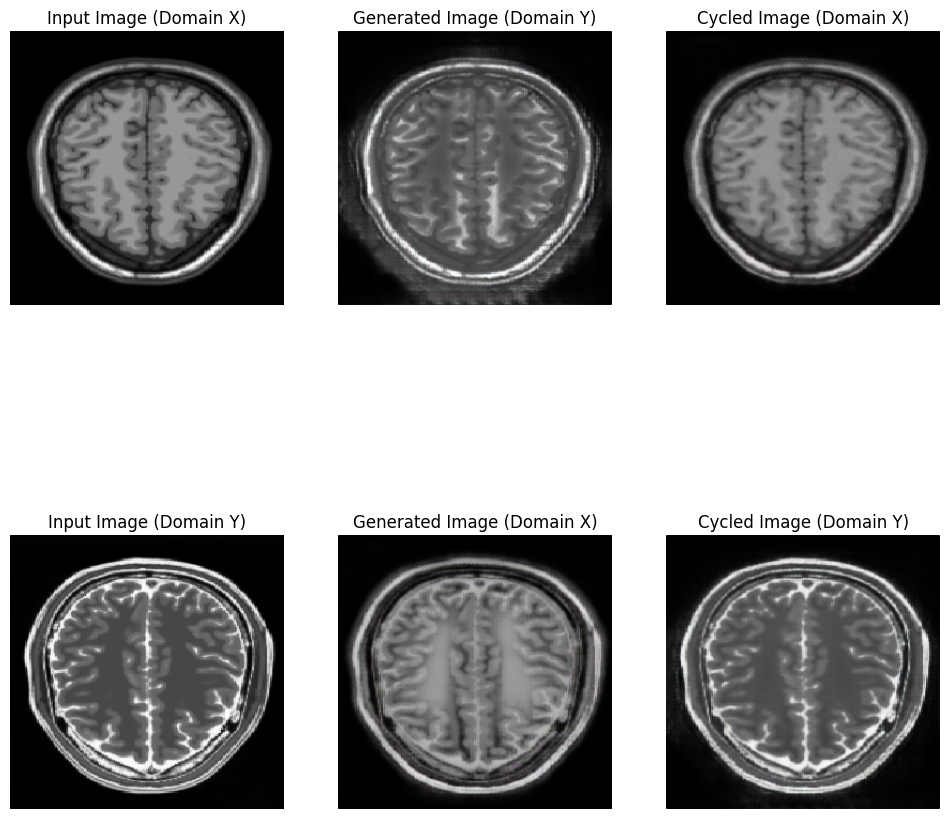

Generated images saved to: /content/drive/MyDrive/cyclegan_generated_images/generated_images_20260702-184854.png
--- Test Example 2 ---


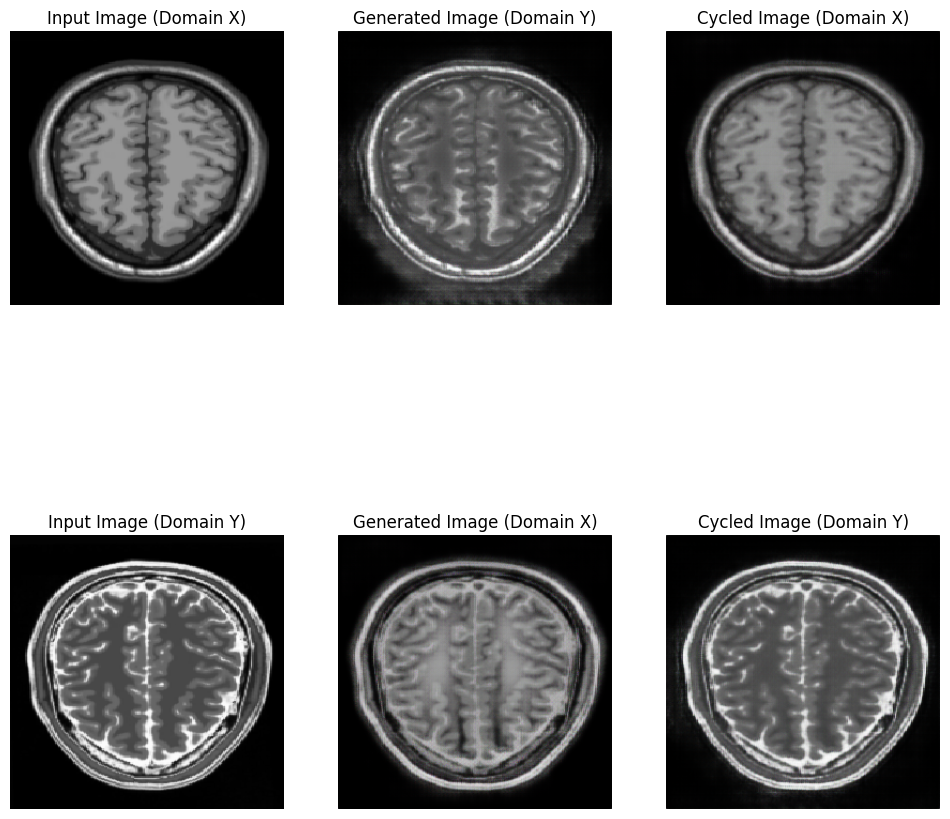

Generated images saved to: /content/drive/MyDrive/cyclegan_generated_images/generated_images_20260702-184856.png


In [19]:
# Define how many examples to display from the test datasets
num_examples_to_display = 5

print(f"Displaying {num_examples_to_display} examples from the test dataset:")

# Iterate through a few examples from both test datasets simultaneously
for i, (test_sample_x, test_sample_y) in enumerate(tf.data.Dataset.zip(test_dataset_A.take(num_examples_to_display), test_dataset_B.take(num_examples_to_display))):
  print(f"--- Test Example {i+1} ---") # Print example separator
  # Call generate_images to visualize the translation for each test sample
  save_generated_images(generator_g, generator_f, test_sample_x, test_sample_y)

## Post-Optimization Performance Evaluation

After re-training the CycleGAN model with the adjusted hyperparameters (`LAMBDA` and `EPOCHS`), it is essential to re-evaluate its performance. This step involves visualizing the generated images once again to qualitatively assess any improvements in translation quality, reduction in artifacts, and overall realism. The expectation is to observe a noticeable enhancement in the synthesized MRI images compared to the initial training phase, thereby validating the hyperparameter tuning efforts.

In [20]:
print("TensorFlow version:", tf.__version__) # Print the installed TensorFlow version
print("Num GPUs Available: ", len(tf.config.experimental.list_physical_devices('GPU'))) # List available GPUs
print("Is GPU available:", tf.test.is_gpu_available()) # Check if a GPU is available and being used by TensorFlow

Instructions for updating:
Use `tf.config.list_physical_devices('GPU')` instead.


TensorFlow version: 2.20.0
Num GPUs Available:  1
Is GPU available: True


### Batch SSIM Calculation for the Entire Test Dataset

This function `calculate_average_ssim` will iterate through all images in both `test_dataset_A` and `test_dataset_B`. For each pair, it will:
1. Generate a translated image using `generator_g` (A to B) and `generator_f` (B to A).
2. Denormalize both the real and generated images from the `[-1, 1]` range (as output by the generators) to the `[0, 1]` range, which is suitable for `tf.image.ssim` with `max_val=1.0`.
3. Calculate the SSIM score between the real image and its generated translation.
4. Collect all SSIM scores and return the average for both translation directions (A to B, and B to A).

In [23]:
def calculate_average_ssim(generator_g, generator_f, test_ds_a, test_ds_b):
  ssim_scores_a_to_b = [] # Stores SSIM for real A vs generated B
  ssim_scores_b_to_a = [] # Stores SSIM for real B vs generated A

  # Iterate through the entire test dataset
  for real_a_batch, real_b_batch in tf.data.Dataset.zip(test_ds_a, test_ds_b):
    # Generate fake images
    fake_b_batch = generator_g(real_a_batch, training=False) # A -> B
    fake_a_batch = generator_f(real_b_batch, training=False) # B -> A

    # Denormalize images from [-1, 1] to [0, 1] for SSIM calculation
    # SSIM expects values in a defined range, max_val=1.0 when images are in [0, 1]
    denormalized_real_a = (real_a_batch * 0.5 + 0.5)
    denormalized_fake_b = (fake_b_batch * 0.5 + 0.5)
    denormalized_real_b = (real_b_batch * 0.5 + 0.5)
    denormalized_fake_a = (fake_a_batch * 0.5 + 0.5)

    # Calculate SSIM for each image in the batch
    for i in range(tf.shape(real_a_batch)[0]): # Iterate through the batch
      ssim_ab = tf.image.ssim(denormalized_real_a[i], denormalized_fake_b[i], max_val=1.0)
      ssim_scores_a_to_b.append(ssim_ab.numpy())

    for i in range(tf.shape(real_b_batch)[0]): # Iterate through the batch
      ssim_ba = tf.image.ssim(denormalized_real_b[i], denormalized_fake_a[i], max_val=1.0)
      ssim_scores_b_to_a.append(ssim_ba.numpy())

  # Calculate average SSIM scores
  avg_ssim_a_to_b = np.mean(ssim_scores_a_to_b) if ssim_scores_a_to_b else 0.0
  avg_ssim_b_to_a = np.mean(ssim_scores_b_to_a) if ssim_scores_b_to_a else 0.0

  return avg_ssim_a_to_b, avg_ssim_b_to_a

# Call the function to calculate SSIM for the entire test dataset
print("Calculating average SSIM for the entire test dataset...")
avg_ssim_t1_to_t2, avg_ssim_t2_to_t1 = calculate_average_ssim(generator_g, generator_f, test_dataset_A, test_dataset_B)

print(f"Average SSIM (T1 to T2): {avg_ssim_t1_to_t2:.4f}")
print(f"Average SSIM (T2 to T1): {avg_ssim_t2_to_t1:.4f}")

Calculating average SSIM for the entire test dataset...
Average SSIM (T1 to T2): 0.5873
Average SSIM (T2 to T1): 0.6807


## Checkpointing Strategy for Model Persistence

Implementing a robust checkpointing mechanism is paramount in deep learning projects, especially for time-consuming training processes like GANs. This strategy enables the periodic saving of the model's weights and optimizer states, offering several critical advantages:

*   **Fault Tolerance**: In the event of interruptions (e.g., Colab runtime disconnections, system crashes), training can be resumed from the last saved checkpoint, preventing loss of progress.
*   **Iterative Development**: Allows for experimentation with different hyperparameters or architectural modifications, with the ability to revert to a stable, previously saved state.
*   **Deployment**: Provides trained model weights that can be loaded for inference or deployment in new environments.

This section defines the checkpoint path within Google Drive to ensure persistence across sessions and configures the `tf.train.CheckpointManager` to manage checkpoint saving, retaining the most recent `k` checkpoints.

In [24]:
# Define the directory in Google Drive where you want to save the checkpoints
# This ensures checkpoints are persistent across Colab sessions.
checkpoint_path = os.path.join(PATH, 'cyclegan_checkpoints')

# Create the checkpoint directory if it does not already exist
if not os.path.exists(checkpoint_path):
    os.makedirs(checkpoint_path)

print(f"Updated checkpoint_path to: {checkpoint_path}") # Display the path where checkpoints will be saved

Updated checkpoint_path to: /content/drive/MyDrive/MRI-T1-T2-Dataset-1/cyclegan_checkpoints


In [25]:
# Create a tf.train.Checkpoint object to save the state of all models and optimizers
ckpt = tf.train.Checkpoint(generator_g=generator_g,
                           generator_f=generator_f,
                           discriminator_x=discriminator_x,
                           discriminator_y=discriminator_y,
                           generator_g_optimizer=generator_g_optimizer,
                           generator_f_optimizer=generator_f_optimizer,
                           discriminator_x_optimizer=discriminator_x_optimizer,
                           discriminator_y_optimizer=discriminator_y_optimizer)

# Create a tf.train.CheckpointManager to manage saving and restoring checkpoints
# It keeps track of the latest 'max_to_keep' checkpoints.
ckpt_manager = tf.train.CheckpointManager(ckpt, checkpoint_path, max_to_keep=5)

# Save the latest checkpoint to Google Drive
save_path = ckpt_manager.save() # This returns the path to the newly saved checkpoint
print(f"Saved checkpoint to {save_path}") # Confirm where the checkpoint was saved

Saved checkpoint to /content/drive/MyDrive/MRI-T1-T2-Dataset-1/cyclegan_checkpoints/ckpt-1


## Discussion on Quantitative Metrics and Future Work

The visual inspections conducted thus far provide valuable qualitative insights into the CycleGAN's performance. However, for a more rigorous and objective evaluation, the integration of quantitative metrics is essential. While more complex to implement for unpaired image-to-image translation tasks, metrics such as Frechet Inception Distance (FID) and Structural Similarity Index (SSIM) can offer numerical assessments of generated image quality and similarity to real images.

### Future Work and Enhancements:

*   **Quantitative Evaluation**: Implement and analyze FID, SSIM, and potentially perceptual similarity metrics to provide a data-driven assessment of model performance.
*   **Larger Datasets**: Train the model on more extensive and diverse MRI datasets to improve generalization and robustness.
*   **Advanced Architectures**: Explore alternative or more sophisticated generator and discriminator architectures (e.g., attention mechanisms, different normalization layers) to further enhance image quality.
*   **Clinical Validation**: Collaborate with medical professionals to assess the clinical utility and diagnostic value of the translated images.
*   **Computational Efficiency**: Investigate methods for further optimizing training speed and memory usage, especially for deployment on resource-constrained devices.

This Capstone project lays a solid foundation for MRI image translation, and these future directions aim to push the boundaries of its practical applicability and performance.

## Comprehensive Model Architecture Summary

This section provides a detailed summary of the architectural configurations for both the `Generator` (specifically `generator_g` as a representative example) and the `Discriminator` (specifically `discriminator_x` as a representative example). These summaries delineate the layer-by-layer composition, output shapes, and the total number of trainable parameters for each network. Understanding these structural details is crucial for comprehending the model's complexity and its capacity for learning intricate image transformations and discriminations.

In [26]:
print('--- Generator (U-Net) Architecture Summary ---') # Informative print statement
generator_g.summary() # Print the summary of the generator_g model, including layers, output shapes, and parameters

--- Generator (U-Net) Architecture Summary ---


Model: "functional_35"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_19      │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_18       │ (None, 128, 128,  │      3,072 │ input_layer_19[0… │
│ (Sequential)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_19       │ (None, 64, 64,    │    131,584 │ sequential_18[0]… │
│ (Sequential)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_20       │ (None, 32, 32,    │    525,312 │ sequential_19[0]… │
│ (Sequential)        │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_21       │ (None, 16, 16,    │  2,099,200 │ sequential_20[0]… │
│ (Sequential)        │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_22       │ (None, 8, 8, 512) │  4,196,352 │ sequential_21[0]… │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_23       │ (None, 4, 4, 512) │  4,196,352 │ sequential_22[0]… │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_24       │ (None, 2, 2, 512) │  4,196,352 │ sequential_23[0]… │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_25       │ (None, 1, 1, 512) │  4,196,352 │ sequential_24[0]… │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_26       │ (None, 2, 2, 512) │  4,196,352 │ sequential_25[0]… │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_7       │ (None, 2, 2,      │          0 │ sequential_26[0]… │
│ (Concatenate)       │ 1024)             │            │ sequential_24[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_27       │ (None, 4, 4, 512) │  8,390,656 │ concatenate_7[0]… │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_8       │ (None, 4, 4,      │          0 │ sequential_27[0]… │
│ (Concatenate)       │ 1024)             │            │ sequential_23[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_28       │ (None, 8, 8, 512) │  8,390,656 │ concatenate_8[0]… │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_9       │ (None, 8, 8,      │          0 │ sequential_28[0]… │
│ (Concatenate)       │ 1024)             │            │ sequential_22[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_29       │ (None, 16, 16,    │  8,390,656 │ concatenate_9[0]… │
│ (Sequential)        │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_10      │ (None, 16, 16,    │          0 │ sequential_29[0]

 Total params: 54,425,859 (207.62 MB)

 Trainable params: 54,414,979 (207.58 MB)

 Non-trainable params: 10,880 (42.50 KB)

In [27]:
print('\n--- Discriminator (PatchGAN) Architecture Summary ---') # Informative print statement with newline
discriminator_x.summary() # Print the summary of the discriminator_x model, including layers, output shapes, and parameters


--- Discriminator (PatchGAN) Architecture Summary ---


Model: "functional_55"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_48 (Sequential)      │ (None, 128, 128, 64)   │         3,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_49 (Sequential)      │ (None, 64, 64, 128)    │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_50 (Sequential)      │ (None, 32, 32, 256)    │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ zero_padding2d_2                │ (None, 34, 34, 256)    │             0 │
│ (ZeroPadding2D)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_32 (Conv2D)              │ (None, 31, 31, 512)    │     2,097,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_47          │ (None, 31, 31, 512)    │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_31 (LeakyReLU)      │ (None, 31, 31, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ zero_padding2d_3                │ (None, 33, 33, 512)    │             0 │
│ (ZeroPadding2D)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_33 (Conv2D)              │ (None, 30, 30, 1)      │         8,193 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,767,361 (10.56 MB)

 Trainable params: 2,765,569 (10.55 MB)

 Non-trainable params: 1,792 (7.00 KB)